<div>
<img src="https://www.cosmos.esa.int/documents/3414525/0/Logo_Gaia_may_23_2022.png/cf6be61e-609e-27dc-3ad6-03ac5209bdc4?t=1653299950248" width="300" align="right"/>
</div>

# Tutorial:  Download DataLink products for >5000 sources

<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />


---
Copyright (c) European Space Agency, 2025.

This file is subject to the terms and conditions defined in file **[LICENSE.txt](LICENSE.txt)**, which
is part of this source code package. No part of the package, including
this file, may be copied, modified, propagated, or distributed except according to
the terms contained in the file **[LICENSE.txt](LICENSE.txt)**.

---



**Release number:** 
v1.2 (2025-05-30)


**Applicable Gaia Data Releases:**
Gaia EDR3, Gaia DR3


**Summary:** 

This Jupyter Notebook allows to overcome the Gaia Archive DataLink products download threshold (5,000 sources) by first splitting an input source list into multiple chunks of 500 sources each. Our tests show that:
* retrieving the data in chunks is at least three times faster (exact values depend on the selected product and file format) than retrieving the data individually (one call per product per source ID), and
* varying the chunk sizes between 50 and 1,000 sources has negligible impact in the total download time.

In this tutorial, we set: 
* the chunk size to 500 elements (source IDs),
* the data structure to INDIVIDUAL, and
* the format to [VOTable](https://www.ivoa.net/documents/VOTable/) 

See the [DataLink: products serialisation](https://www.cosmos.esa.int/web/gaia-users/archive/datalink-products#datalink_serialisation) tutorial for info about the data structures and formats served by the Gaia Archive. The complementary [tutorial_datalink_download.ipynb](tutorial_datalink_download.ipynb) shows how to download  and inspect all the different DataLink products via [Astroquery.Gaia](https://astroquery.readthedocs.io/en/latest/gaia/gaia.html) for a small sample of sources. 



**Useful URLs:**

* [Questions or suggestions](https://www.cosmos.esa.int/web/gaia/questions)
* [Tutorials, documentation, and more](https://www.cosmos.esa.int/web/gaia-users/archive)
* [Known issues in the Gaia data](https://www.cosmos.esa.int/web/gaia-users/known-issues)
* [Gaia data credits and acknowledgements](https://www.cosmos.esa.int/web/gaia-users/credits)
* [GaiaXPy](https://gaia-dpci.github.io/GaiaXPy-website/): GaiaXPy is a Python library to facilitate handling Gaia BP/RP spectra as distributed from the Gaia archive.
* [Astropy: VOTable XML handling](https://docs.astropy.org/en/stable/io/votable/index.html)

In [1]:
from astropy.table import Table
from astroquery.gaia import Gaia
import matplotlib.pyplot as plt

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Important: Gaia archive will be intermittently unavailable due to scheduled maintenance (deployment of a new version) on Wednesday 4th from 11h to 12h


In [2]:
def chunks(lst, n):
    ""
    "Split an input list into multiple chunks of size =< n"
    ""
    for i in range(0, len(lst), n):
        yield lst[i:i + n]

def plot_e_phot(inp_table, colours  = ['green', 'red', 'blue'], title = '', fontsize = 12, show_legend = True, show_grid = True, figsize = [20,5]):
    ""
    "Epoch photometry plotter. 'inp_table' MUST be an Astropy-table object."
    ""       
    fig       = plt.figure(figsize=figsize)
    time_zero = 2455197.5 # See: https://gea.esac.esa.int/archive/documentation/GDR3/Gaia_archive/chap_datamodel/sec_dm_photometry/ssec_dm_epoch_photometry.html#epoch_photometry-g_transit_time
    xlabel    = f'JD date [TCB - {time_zero}]'
    ylabel    = f'magnitude'
    
    plt.gca().invert_yaxis()
    plt.plot(inp_table['g_transit_time'], inp_table['g_transit_mag'], 'o', label = 'G',  color = 'green')
    plt.plot(inp_table['bp_obs_time'],    inp_table['bp_mag'],        'o', label = 'BP', color = 'blue')
    plt.plot(inp_table['rp_obs_time'],    inp_table['rp_mag'],        'o', label = 'RP', color = 'red')
    make_canvas(title = title, xlabel = xlabel, ylabel = ylabel, fontsize= fontsize, show_legend=show_legend, show_grid = show_grid)
    plt.show()


def plot_sampled_spec(inp_table, color = 'blue', title = '', fontsize = 14, show_legend = True, show_grid = True, linewidth = 2, figsize = [20,5], show_plot = True):
    ""
    "RVS & XP sampled spectrum plotter. 'inp_table' MUST be an Astropy-table object."
    ""       
    if show_plot:
        fig      = plt.figure(figsize=figsize)
    xlabel   = f'Wavelength [{inp_table["wavelength"].unit}]'
    ylabel   = f'Flux [{inp_table["flux"].unit}]'
    plt.plot(inp_table['wavelength'], inp_table['flux'], '-', linewidth = linewidth)
    make_canvas(title = title, xlabel = xlabel, ylabel = ylabel, fontsize= fontsize, show_legend=False, show_grid = show_grid)
    if show_plot:
        plt.show()


def make_canvas(title = '', xlabel = '', ylabel = '', show_grid = False, show_legend = False, fontsize = 12):
    ""
    "Create generic canvas for plots"
    ""
    plt.title(title,    fontsize = fontsize)
    plt.xlabel(xlabel,  fontsize = fontsize)
    plt.ylabel(ylabel , fontsize = fontsize)
    plt.xticks(fontsize = fontsize)
    plt.yticks(fontsize = fontsize)
    if show_grid:
        plt.grid()
    if show_legend:
        plt.legend(fontsize = fontsize*1.25)

## Connect to the Gaia Archive

The DataLink products are available to both registered & anonymous users. However, we recommend to access as a registered user due to their extra benefits when executing long queries (as explained in this [FAQ](https://www.cosmos.esa.int/web/gaia-users/archive/faq#account-limits-2020)).

In [3]:
Gaia.login()

INFO: Login to gaia TAP server [astroquery.gaia.core]


User:  hcanovas
Password:  ········


INFO: OK [astroquery.utils.tap.core]
INFO: Login to gaia data server [astroquery.gaia.core]
INFO: OK [astroquery.utils.tap.core]


##  Execute ADQL Query

The query below retrieves data for 5100 sources that have associated all the DataLink products offered in Gaia DR3.

In [4]:
query = "SELECT TOP 5100 source_id, ra, dec, parallax from gaiadr3.gaia_source \
WHERE has_epoch_photometry = 'True' AND \
has_mcmc_gspphot = 'True' AND \
has_mcmc_msc = 'True' AND \
has_xp_sampled = 'True' AND \
has_rvs = 'True'"

job     = Gaia.launch_job_async(query)
results = job.get_results()
results[0:5]

INFO: Query finished. [astroquery.utils.tap.core]


source_id,ra,dec,parallax
,deg,deg,mas
int64,float64,float64,float64
2263166706630078848,295.13035167754015,70.28624696426813,17.357227526090668
2263178457660566784,294.86955515586925,70.52640371163079,5.99456673538563
2268372099615724288,285.63663592006975,75.41851051257491,23.857068308325488
5912901375001820288,263.99225124991324,-58.82661905857226,6.476061657906406
2266609140096698112,275.7457014457717,72.17444369607303,7.253739784978569


## Download Datalink Products

**Warning**: The ```load_data``` method allows to retrieve all types of DataLink products (epoch photometry, MCMC's, and spectra) in one single call (see below). However, selecting this option when attempting to retrieve DataLink products for large (>1000) amount of sources can severely delay the dataset preparation on the server side, and even result in a download error. Therefore, we strongly recommend to select one a product at a time in this case.

### Split the input list into several chunks containing =<500 elements each, and store the data locally.

Notes:
* The total download time of the example below is ~200 seconds.
* The DataLink products are stored inside gzip compressed files named as "datalink_output_<yyyymmddThhmmss>.zip"

In [5]:
chunk_size   = 500
ids          = results['source_id']
ids_chunks   = list(chunks(ids, chunk_size))
datalink_all = []


print(f'* Input list contains {len(ids)} source_IDs')
print(f'* This list is split into {len(ids_chunks)} chunks of <= {chunk_size} elements each')

* Input list contains 5100 source_IDs
* This list is split into 11 chunks of <= 500 elements each


In [6]:
retrieval_type = 'RVS'        # Options are: 'EPOCH_PHOTOMETRY', 'MCMC_GSPPHOT', 'MCMC_MSC', 'XP_SAMPLED', 'XP_CONTINUOUS', 'RVS' 
data_structure = 'INDIVIDUAL' # Options are: 'INDIVIDUAL' and 'RAW'.
data_release   = 'Gaia DR3'   # Options are: 'Gaia DR3' (default), 'Gaia DR2'

datalink_all   = []

ii = 0
for chunk in ids_chunks:
    ii = ii + 1
    print(f'Downloading Chunk #{ii}; N_files = {len(chunk)}')
    datalink  = Gaia.load_data(ids=chunk, data_release = data_release, retrieval_type=retrieval_type, format = 'votable', data_structure = data_structure, dump_to_file=True)
    datalink_all.append(datalink)

INFO: DataLink products will be stored in the /Users/hcanovas/Library/CloudStorage/OneDrive-ESA/job/gaia_sco9/help_pages/tutorials/programmatic/git_dir/gaia-esa-archive-tutorials/datalink_output_20250602T123947.603623.zip file [astroquery.gaia.core]
INFO: DataLink products will be stored in the /Users/hcanovas/Library/CloudStorage/OneDrive-ESA/job/gaia_sco9/help_pages/tutorials/programmatic/git_dir/gaia-esa-archive-tutorials/datalink_output_20250602T124007.369620.zip file [astroquery.gaia.core]
INFO: DataLink products will be stored in the /Users/hcanovas/Library/CloudStorage/OneDrive-ESA/job/gaia_sco9/help_pages/tutorials/programmatic/git_dir/gaia-esa-archive-tutorials/datalink_output_20250602T124026.931474.zip file [astroquery.gaia.core]
INFO: DataLink products will be stored in the /Users/hcanovas/Library/CloudStorage/OneDrive-ESA/job/gaia_sco9/help_pages/tutorials/programmatic/git_dir/gaia-esa-archive-tutorials/datalink_output_20250602T124046.463422.zip file [astroquery.gaia.core]


### Merge chunks into one single object (Python dictionary)

In [7]:
datalink_out = datalink_all[0]

for inp_dict in datalink_all[1:]:
    datalink_out.update(inp_dict)

keys = list(datalink_out.keys())
print(f'* The merged dictionary contains {len(keys)} elements')

* The merged dictionary contains 5100 elements


File metadata:
----------------------------------------------------------------------------------------------------------------------------------------------------------------
<PARAM ID="source_id" datatype="long" name="source_id" ucd="meta.id;meta.main" value="5817850518933465216"/>
<PARAM ID="solution_id" datatype="long" name="solution_id" ucd="meta.version" value="5950420259779346465"/>
<PARAM ID="combined_transits" datatype="int" name="combined_transits" ucd="meta.number" value="30"/>
<PARAM ID="combined_ccds" datatype="int" name="combined_ccds" ucd="meta.number" value="83"/>
<PARAM ID="deblended_ccds" datatype="int" name="deblended_ccds" ucd="meta.number" value="11"/>
<PARAM ID="spatialLocation" arraysize="2" datatype="double" name="spatialLocation" ucd="pos.eq" unit="deg" utype="spec:Char.SpatialAxis.Coverage.Location.Value" value="[252.35787028 -63.58134854]"/>
<PARAM ID="TimeAxisCoverageLocation" datatype="double" name="TimeAxisCoverageLocation" ucd="time.epoch" unit="yr" utype

wavelength,flux,flux_error
nm,,
float64,float32,float32
846.0,0.9846479,0.009583678
846.01,0.9915793,0.01039188
846.02,0.9861507,0.009392991


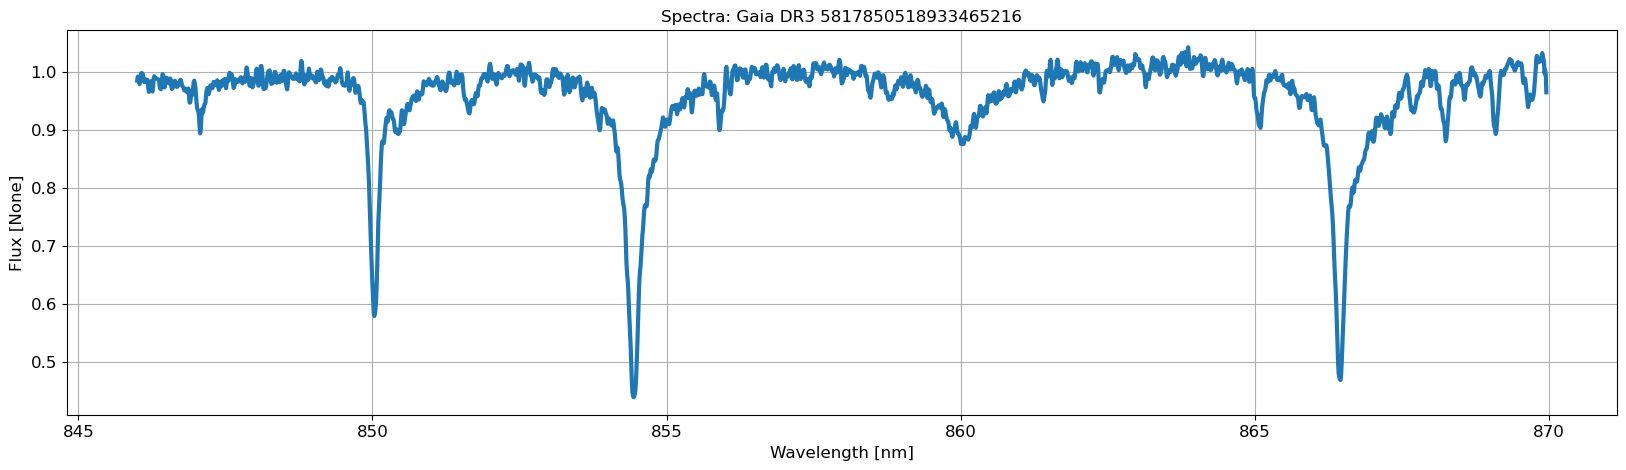

In [8]:
# Examine and display data for one selected element
index = 0

votable  = datalink_out[keys[0]][0]                      # Select the first (and only) element of the list

# Display VOTable metadata ================
print(f'File metadata:')
print('-' * 160)
for item in votable.iter_fields_and_params():
    print(item)

# Display VOTable data ====================
print(f'File data:')
print('-' * 160)
votable_data = votable.to_table()
display(votable_data[0:3])


source_id = votable.get_field_by_id('source_id').value

title     = f'Spectra: Gaia DR3 {source_id}'
plot_sampled_spec(votable_data, title = title, fontsize = 12, show_legend = True, show_grid = True, figsize = [20,5], linewidth= 3)